<a href="https://colab.research.google.com/github/JheniferBritto/nalise-atendimento-otimizacao/blob/main/Python2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# =========================================================
# 📚 1. IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

np.random.seed(42)

# =========================================================
# 🧠 2. CRIAÇÃO DOS DADOS (SIMULAÇÃO)
# =========================================================
tipos = ["reclamação", "elogio", "dúvida", "cancelamento"] # Lista classificações

mensagens_exemplo = {           #Dicionarios de frases
    "reclamação": [
        "Produto chegou quebrado",
        "Não recebi o pedido",
        "Atendimento ruim"
    ],
    "elogio": [
        "Gostei muito do produto",
        "Entrega rápida",
        "Atendente muito educado"
    ],
    "dúvida": [
        "Qual o prazo de entrega?",
        "Como faço para trocar?",
        "Tem garantia?"
    ],
    "cancelamento": [
        "Quero cancelar o pedido",
        "Desejo reembolso",
        "Cancelar assinatura"
    ]
}

dados = []   #lista vazia

for i in range(500):   # criar sequencia de 500
    tipo = random.choice(tipos)  # escolhe aleatoriamente um tipo de palavra
    texto = random.choice(mensagens_exemplo[tipo]) # escolhe aleatoriamente um tipo de mensagem e palavra
    dados.append([texto, tipo]) #adicione na lista mensagems e palavras

df = pd.DataFrame(dados, columns=["mensagem", "categoria"]) # transforme em tabela e as colunas vai ser mensagem e categoria

print("\n📊 Amostra dos dados:")
print(df.head()) #mostra a tabela




📊 Amostra dos dados:
                  mensagem   categoria
0      Não recebi o pedido  reclamação
1  Gostei muito do produto      elogio
2  Atendente muito educado      elogio
3      Não recebi o pedido  reclamação
4  Produto chegou quebrado  reclamação


In [32]:
# =========================================================
# 🤖 3. MACHINE LEARNING (CLASSIFICAÇÃO)
# =========================================================

# transformar texto em número
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["mensagem"])

# variável alvo (resposta)
y = df["categoria"]

# dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2)

# criar modelo
modelo = MultinomialNB()

# treinar modelo
modelo.fit(X_train, y_train)

# fazer previsão
pred = modelo.predict(X_test)

print("\n📈 RELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, pred))



📈 RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

cancelamento       1.00      1.00      1.00        34
      dúvida       1.00      1.00      1.00        21
      elogio       1.00      1.00      1.00        20
  reclamação       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [33]:
freq = df["categoria"].value_counts()
freq.sum()

np.int64(500)


📊 Frequência por categoria:
categoria
elogio          127
cancelamento    127
reclamação      125
dúvida          121
Name: count, dtype: int64


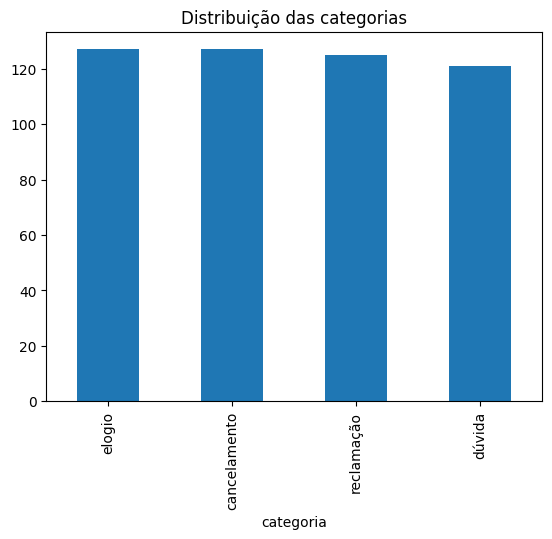

In [34]:
# =========================================================
# 📊 4. ANÁLISE DAS CATEGORIAS
# =========================================================
freq = df["categoria"].value_counts()

print("\n📊 Frequência por categoria:")
print(freq)

freq.plot(kind="bar", title="Distribuição das categorias")
plt.show()


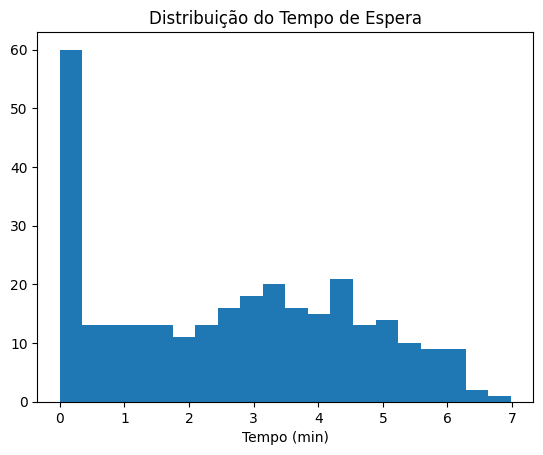


 Tempo médio de espera:
2.64


In [35]:
# =========================================================
# ⏱️ 5. SIMULAÇÃO DE FILA
# =========================================================

tempo_chegada = np.random.exponential(scale=3, size=300)
tempo_atendimento = np.random.normal(loc=5, scale=1, size=300)

tempo_espera = np.maximum(tempo_atendimento - tempo_chegada, 0)

df_fila = pd.DataFrame({
    "chegada": tempo_chegada,
    "atendimento": tempo_atendimento,
    "espera": tempo_espera
})

plt.hist(df_fila["espera"], bins=20)
plt.title("Distribuição do Tempo de Espera")
plt.xlabel("Tempo (min)")
plt.show()

print("\n Tempo médio de espera:")
print(round(df_fila["espera"].mean(),2))


In [36]:
# =========================================================
# 🔐 6. ANONIMIZAÇÃO DE DADOS
# =========================================================

def anonimizar(texto):
    return texto.replace("pedido", "[DADO]").replace("produto", "[DADO]")

df["mensagem_anonima"] = df["mensagem"].apply(anonimizar)

print("\n🔒 Mensagens anonimizadas:")
print(df[["mensagem", "mensagem_anonima"]].head())




🔒 Mensagens anonimizadas:
                  mensagem         mensagem_anonima
0      Não recebi o pedido      Não recebi o [DADO]
1  Gostei muito do produto   Gostei muito do [DADO]
2  Atendente muito educado  Atendente muito educado
3      Não recebi o pedido      Não recebi o [DADO]
4  Produto chegou quebrado  Produto chegou quebrado


In [37]:
# =========================================================
# 🧪 7. TESTE COM NOVA FRASE
# =========================================================

nova_frase = ["desejo cancelar"]

nova_transformada = vectorizer.transform(nova_frase)

previsao = modelo.predict(nova_transformada)

print("\n🤖 Previsão para nova frase:")
print(previsao)


🤖 Previsão para nova frase:
['cancelamento']
